# Φάση Δ: Advanced Technique

Εμείς επιλέξαμε το K-Means


In [52]:
# =====================================================================
# GLOBAL CONFIGURATION FOR K-MEANS
# Αλλάξτε αυτή τη μεταβλητή εδώ και θα εφαρμοστεί αυτόματα σε όλο το notebook
# =====================================================================

SELECTED_K = 4

print(f"Ορίστηκε καθολικό K = {SELECTED_K}. Έτοιμο για χρήση στα επόμενα κελιά.")

Ορίστηκε καθολικό K = 4. Έτοιμο για χρήση στα επόμενα κελιά.


# Εκκίνηση SparkSession & Φόρτωση Δεδομένων

In [53]:
from pyspark.sql import SparkSession

# 1. Εκκίνηση του SparkSession
spark = SparkSession.builder \
    .appName("KMeans_Feature_Exploration") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

print("SparkSession αρχικοποιήθηκε με επιτυχία.")

# 2. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")
train_gold = spark.read.parquet("../data/train_gold.parquet")

print(f"Δεδομένα φορτώθηκαν. Gold Layer σχήμα: {train_gold.schema}")

SparkSession αρχικοποιήθηκε με επιτυχία.
Δεδομένα φορτώθηκαν. Gold Layer σχήμα: StructType([StructField('features', VectorUDT(), True), StructField('stroke', LongType(), True)])


# Εμφάνιση χαρακτηριστικών του Gold Layer

In [54]:
import pyspark.sql.functions as F
from pyspark.ml.functions import vector_to_array
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Βρούμε τις κατηγορικές στήλες (_index) και εξάγουμε τα labels από τα Metadata
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]
human_categorical_names = []

for col in cat_cols:
    metadata = df_silver.schema[col].metadata
    # Αν υπάρχουν metadata από τον StringIndexer, παίρνουμε τα vals
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback native ανάγνωση αν λείπουν τα metadata
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) αφαιρεί πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

# 2. Βρούμε τις αριθμητικές στήλες με τη σωστή σειρά
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]
numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]

# 3. Ενώνουμε τις λίστες με την ακριβή σειρά που μπήκαν στον VectorAssembler (Categorical Vector + Numeric)
feature_names = human_categorical_names + numeric_cols
print(f"Συνολικά βρέθηκαν {len(feature_names)} διαστάσεις στο feature vector.")

# 4. Μετατροπή του Vector σε Array στο train_gold
df_look = train_gold.withColumn("features_array", vector_to_array("features"))

# 5. Χτίζουμε δυναμικά το select expresssion για ΟΛΕΣ τις στήλες
select_exprs = [F.col("stroke")]
for i, name in enumerate(feature_names):
    select_exprs.append(F.col("features_array")[i].alias(name))

# 6. Προβολή των 5 πρώτων γραμμών με όλα τα χαρακτηριστικά επεξηγημένα
df_look.select(select_exprs).show(5, truncate=False)

Συνολικά βρέθηκαν 21 διαστάσεις στο feature vector.
+------+-----------------+-----------------+------------+------------------+---------------+-----------------+-----------------------+------------------+------------------+----------------------+--------------------+--------------------+---------------------------+----------------------+------------------------------+---------------------+------------------+------------+-------------+------------------+-----------------+
|stroke|gender_Female    |gender_Male      |gender_Other|ever_married_Yes  |ever_married_No|work_type_Private|work_type_Self-employed|work_type_children|work_type_Govt_job|work_type_Never_worked|Residence_type_Urban|Residence_type_Rural|smoking_status_never smoked|smoking_status_Unknown|smoking_status_formerly smoked|smoking_status_smokes|age               |hypertension|heart_disease|avg_glucose_level |bmi              |
+------+-----------------+-----------------+------------+------------------+---------------+------

# Εφαρμογή βαρών στο gold για Feature Engineering

In [55]:
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np
import pyspark.sql.functions as F

# 1. Δημιουργούμε έναν πίνακα με βάρη (αρχικά όλα 1.0) ίσο με το μέγεθος των features
num_features = len(feature_names)
weights_array = np.ones(num_features)

# --- FEATURE ENGINEERING: ΜΗΔΕΝΙΣΜΟΣ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΓΙΑ ΚΑΛΥΤΕΡΟ PERFORMANCE ---
# Φιλτράρουμε τις στήλες βάσει ονόματος και μηδενίζουμε όσες εισάγουν θόρυβο
for idx, name in enumerate(feature_names):
    if any(demographic in name for demographic in ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]):
        weights_array[idx] = 0.0

# Προαιρετικά: Μπορείς να δώσεις ακόμα μεγαλύτερη έμφαση στην ηλικία αν θες (π.χ. weights_array[feature_names.index("age")] = 2.0)
# ----------------------------------------------------------------------------------

print("=== ΝΕΟΣ ΠΙΝΑΚΑΣ ΒΑΡΩΝ ===")
for name, weight in zip(feature_names, weights_array):
    print(f"{name}: {weight}")

# 2. UDF για element-wise πολλαπλασιασμό του vector με τα βάρη
apply_weights_udf = F.udf(lambda vec: Vectors.dense(vec.toArray() * weights_array), VectorUDT())

# 3. Δημιουργία του modified_gold στην μνήμη χωρίς να αλλάξουμε το αρχικό αρχείο
modified_gold = train_gold.withColumn("features", apply_weights_udf("features"))

print("\nΤο modified_gold δημιουργήθηκε με επιτυχία και περιέχει μόνο το ιατρικό προφίλ των ασθενών!")

=== ΝΕΟΣ ΠΙΝΑΚΑΣ ΒΑΡΩΝ ===
gender_Female: 0.0
gender_Male: 0.0
gender_Other: 0.0
ever_married_Yes: 0.0
ever_married_No: 0.0
work_type_Private: 0.0
work_type_Self-employed: 0.0
work_type_children: 0.0
work_type_Govt_job: 0.0
work_type_Never_worked: 0.0
Residence_type_Urban: 0.0
Residence_type_Rural: 0.0
smoking_status_never smoked: 0.0
smoking_status_Unknown: 0.0
smoking_status_formerly smoked: 0.0
smoking_status_smokes: 0.0
age: 1.0
hypertension: 1.0
heart_disease: 1.0
avg_glucose_level: 1.0
bmi: 1.0

Το modified_gold δημιουργήθηκε με επιτυχία και περιέχει μόνο το ιατρικό προφίλ των ασθενών!


# Elbow Method & Silhouette Score πάνω στο modified_gold

Μας βοηθάει να επιλέξουμε το σωστό k για το k-Means

Έναρξη αξιολόγησης του modified_gold...
Εκπαίδευση μοντέλου για K = 2...


 -> K = 2: WSSSE = 31600.30 | Silhouette Score = 0.2188
Εκπαίδευση μοντέλου για K = 3...


 -> K = 3: WSSSE = 24098.72 | Silhouette Score = 0.3605
Εκπαίδευση μοντέλου για K = 4...


 -> K = 4: WSSSE = 22633.74 | Silhouette Score = 0.5431
Εκπαίδευση μοντέλου για K = 5...


 -> K = 5: WSSSE = 16229.06 | Silhouette Score = 0.5507
Εκπαίδευση μοντέλου για K = 6...


 -> K = 6: WSSSE = 15116.86 | Silhouette Score = 0.4563
Εκπαίδευση μοντέλου για K = 7...


 -> K = 7: WSSSE = 14023.92 | Silhouette Score = 0.3858
Εκπαίδευση μοντέλου για K = 8...


 -> K = 8: WSSSE = 8055.21 | Silhouette Score = 0.5495


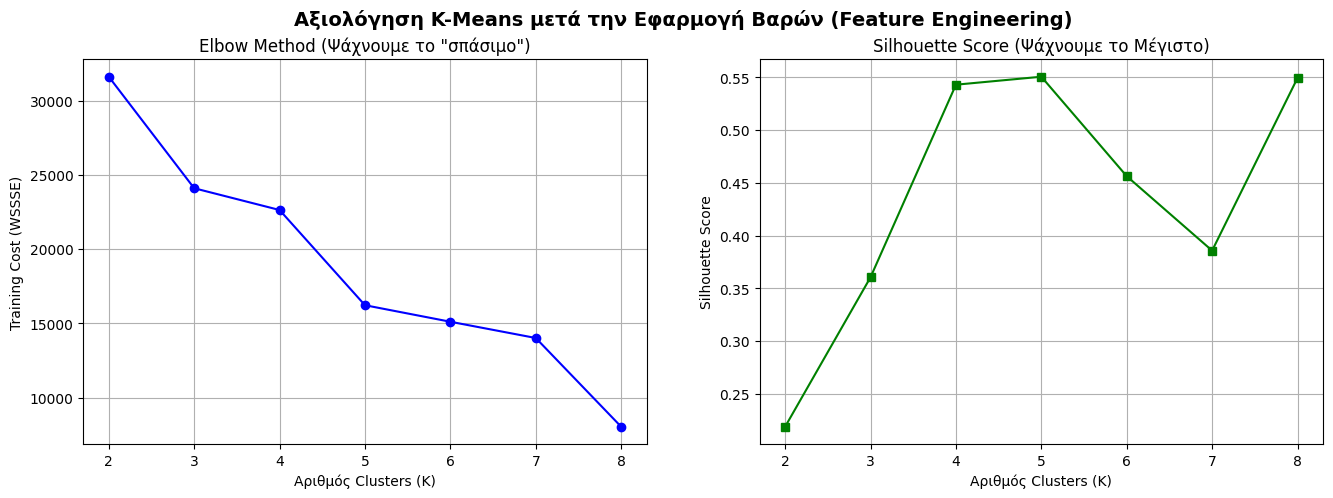

In [56]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print("Έναρξη αξιολόγησης του modified_gold...")

# 1. Αρχικοποίηση λιστών για την αποθήκευση των μετρικών
costs = []
silhouette_scores = []
k_range = range(2, 9)  # Δοκιμάζουμε Κ από 2 έως 8 όπως στην αρχική μελέτη

# 2. Ορισμός του Evaluator για το Silhouette Score
evaluator = ClusteringEvaluator(
    predictionCol="cluster", 
    featuresCol="features", 
    metricName="silhouette"
)

# 3. Εκτέλεση του Loop για κάθε K
for k_val in k_range:
    print(f"Εκπαίδευση μοντέλου για K = {k_val}...")
    
    # Ορισμός και εκπαίδευση του KMeans με σταθερό seed για αναπαραγωγιμότητα
    km = KMeans(featuresCol="features", predictionCol="cluster", k=k_val, seed=42)
    model = km.fit(modified_gold)
    
    # α) Υπολογισμός Training Cost (WSSSE) για την Elbow Method
    cost = model.summary.trainingCost
    costs.append(cost)
    
    # β) Παραγωγή προβλέψεων και υπολογισμός Silhouette Score
    predictions = model.transform(modified_gold)
    score = evaluator.evaluate(predictions)
    silhouette_scores.append(score)
    
    print(f" -> K = {k_val}: WSSSE = {cost:.2f} | Silhouette Score = {score:.4f}")

# 4. Σχεδίαση Γραφημάτων (Δίπλα-Δίπλα για εύκολη σύγκριση)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Γράφημα 1: Elbow Method
ax1.plot(list(k_range), costs, marker='o', linestyle='-', color='b')
ax1.set_xlabel('Αριθμός Clusters (K)')
ax1.set_ylabel('Training Cost (WSSSE)')
ax1.set_title('Elbow Method (Ψάχνουμε το "σπάσιμο")')
ax1.grid(True)

# Γράφημα 2: Silhouette Score
ax2.plot(list(k_range), silhouette_scores, marker='s', linestyle='-', color='g')
ax2.set_xlabel('Αριθμός Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score (Ψάχνουμε το Μέγιστο)')
ax2.grid(True)

plt.suptitle('Αξιολόγηση K-Means μετά την Εφαρμογή Βαρών (Feature Engineering)', fontsize=14, fontweight='bold')
plt.show()

# Ορθή Εφαρμογή PCA σε Train και Test Sets


In [57]:
from pyspark.ml.feature import PCA
import pyspark.sql.functions as F

print("Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...")

# 1. Φόρτωση και του test_gold (αν δεν είναι ήδη φορτωμένο)
test_gold = spark.read.parquet("../data/test_gold.parquet")

# 2. Ορισμός του PCA μοντέλου
# Επιλέγουμε k=2 κυρίως συστατώσες για να μπορούμε να κάνουμε 2D οπτικοποίηση
pca = PCA(k=2, inputCol="features", outputCol="pca_features")

# 3. ΕΚΠΑΙΔΕΥΣΗ (Fit) ΜΟΝΟ ΣΤΟ TRAIN GOLD
# Υπολογισμός των ιδιοδιανυσμάτων αποκλειστικά από τα δεδομένα εκπαίδευσης
pca_model = pca.fit(train_gold)

# 4. ΜΕΤΑΣΧΗΜΑΤΙΣΜΟΣ (Transform) ΚΑΙ ΣΤΑ ΔΥΟ DATASETS
# Εφαρμόζουμε την ίδια ακριβώς προβολή και στα δύο σύνολα
train_pca = pca_model.transform(train_gold)
test_pca = pca_model.transform(test_gold)

# 5. Επιβεβαίωση αποτελεσμάτων και εμφάνιση δείγματος
print("\n=== TRAIN DATASET ΜΕ PCA FEATURES ===")
train_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

print("=== TEST DATASET ΜΕ PCA FEATURES ===")
test_pca.select("stroke", "features", "pca_features").show(3, truncate=True)

# Επεξήγηση της διακύμανσης (Explained Variance)
explained_variance = pca_model.explainedVariance
print(f"\nΠοσοστό πληροφορίας που διατηρήθηκε:")
print(f" -> PC1: {explained_variance[0]*100:.2f}%")
print(f" -> PC2: {explained_variance[1]*100:.2f}%")
print(f" -> Συνολική πληροφορία (PC1 + PC2): {sum(explained_variance)*100:.2f}%")

Έναρξη διαδικασίας μείωσης διαστασιμότητας με PCA (k=2)...

=== TRAIN DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     1|(21,[1,3,6,11,15,...|[3.77838097358701...|
|     1|(21,[0,3,5,11,13,...|[3.24350473472570...|
|     1|(21,[1,3,5,11,12,...|[4.50903673772673...|
+------+--------------------+--------------------+
only showing top 3 rows
=== TEST DATASET ΜΕ PCA FEATURES ===
+------+--------------------+--------------------+
|stroke|            features|        pca_features|
+------+--------------------+--------------------+
|     0|(21,[0,4,7,11,13,...|[-2.7579359847908...|
|     0|(21,[0,4,7,11,13,...|[-2.5739401657464...|
|     0|(21,[0,4,7,10,13,...|[-2.5704807508333...|
+------+--------------------+--------------------+
only showing top 3 rows

Ποσοστό πληροφορίας που διατηρήθηκε:
 -> PC1: 18.22%
 -> PC2: 11.72%
 -> Συνολική πληροφορία (PC1 + PC

Εκπαίδευση K-Means (K=4) πάνω στα PCA χαρακτηριστικά...


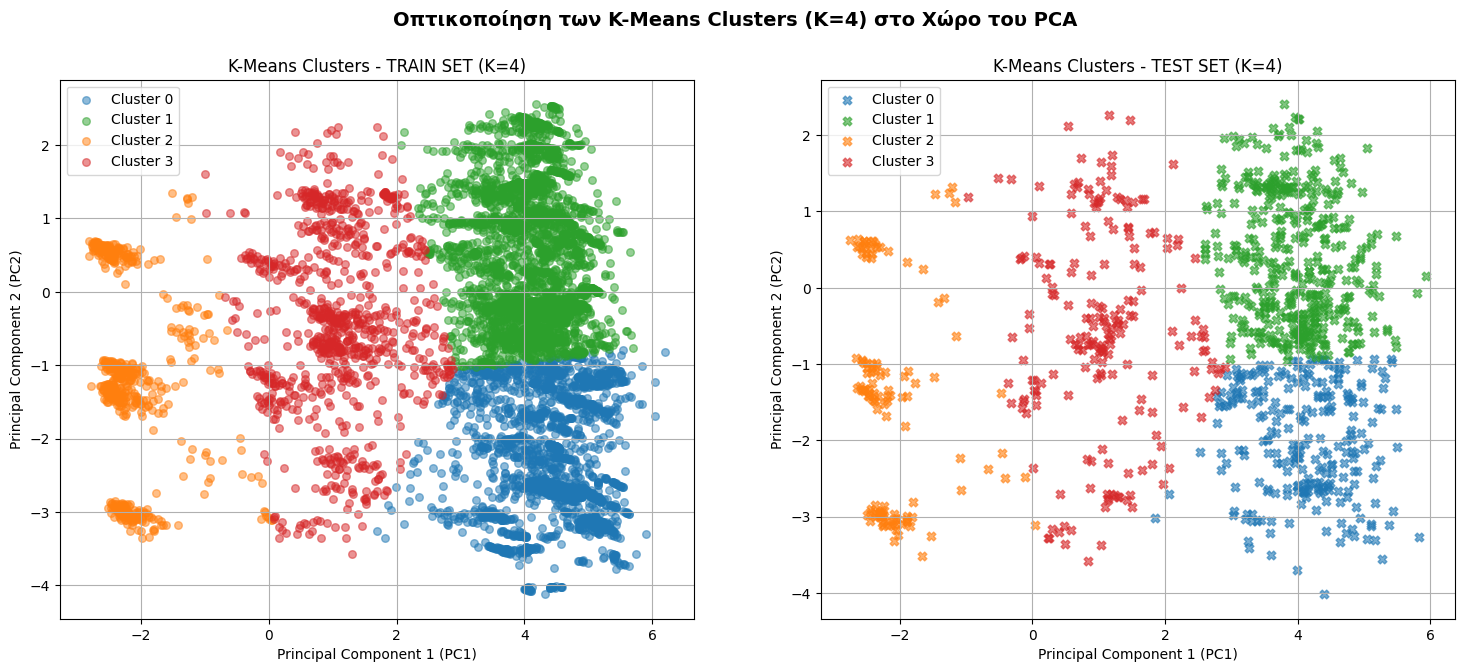

In [58]:
import matplotlib.pyplot as plt
import pandas as pd
from pyspark.ml.clustering import KMeans

print(f"Εκπαίδευση K-Means (K={SELECTED_K}) πάνω στα PCA χαρακτηριστικά...")

# 1. Ορισμός και εκπαίδευση του μοντέλου KMeans στα PCA χαρακτηριστικά του Train set
kmeans_pca = KMeans(featuresCol="pca_features", predictionCol="cluster", k=SELECTED_K, seed=22390225)
model_pca = kmeans_pca.fit(train_pca)

# 2. Παραγωγή προβλέψεων (Cluster Assignments) για Train και Test
train_preds = model_pca.transform(train_pca)
test_preds = model_pca.transform(test_pca)

# 3. Μετατροπή σε Pandas ΜΟΝΟ για τη σχεδίαση των γραφημάτων
plot_train_df = train_preds.select("pca_features", "cluster").toPandas()
plot_test_df = test_preds.select("pca_features", "cluster").toPandas()

# Συνάρτηση για την εξαγωγή των PC1 και PC2 από το Vector σε ξεχωριστές στήλες Pandas
def extract_pcs(df):
    df['PC1'] = df['pca_features'].apply(lambda vec: float(vec[0]))
    df['PC2'] = df['pca_features'].apply(lambda vec: float(vec[1]))
    return df

plot_train_df = extract_pcs(plot_train_df)
plot_test_df = extract_pcs(plot_test_df)

# 4. Δημιουργία των Γραφημάτων (Δίπλα-Δίπλα)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# ΕΝΗΜΕΡΩΜΕΝΟ: Λεξικό με 5 χρώματα για τα Clusters 0, 1, 2, 3, 4
colors = {
    0: '#1f77b4',  # Μπλε
    1: '#2ca02c',  # Πράσινο
    2: '#ff7f0e',  # Πορτοκαλί
    3: '#d62728',  # Κόκκινο
    4: '#9467bd'   # Μοβ
}

# Γράφημα Α: Train Set Clusters
for cluster_id in sorted(plot_train_df['cluster'].unique()):
    cluster_data = plot_train_df[plot_train_df['cluster'] == cluster_id]
    # Μετατροπή του cluster_id σε απλό int για ασφάλεια με το mapping του dict
    cid_int = int(cluster_id)
    ax1.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors.get(cid_int, '#7f7f7f'), alpha=0.5, s=30,
        label=f'Cluster {cid_int}'
    )
ax1.set_xlabel('Principal Component 1 (PC1)')
ax1.set_ylabel('Principal Component 2 (PC2)')
ax1.set_title(f'K-Means Clusters - TRAIN SET (K={SELECTED_K})')
ax1.legend()
ax1.grid(True)

# Γράφημα Β: Test Set Clusters (Γενίκευση Μοντέλου)
for cluster_id in sorted(plot_test_df['cluster'].unique()):
    cluster_data = plot_test_df[plot_test_df['cluster'] == cluster_id]
    cid_int = int(cluster_id)
    ax2.scatter(
        cluster_data['PC1'], cluster_data['PC2'],
        color=colors.get(cid_int, '#7f7f7f'), alpha=0.6, s=40, marker='X',
        label=f'Cluster {cid_int}'
    )
ax2.set_xlabel('Principal Component 1 (PC1)')
ax2.set_ylabel('Principal Component 2 (PC2)')
ax2.set_title(f'K-Means Clusters - TEST SET (K={SELECTED_K})')
ax2.legend()
ax2.grid(True)

plt.suptitle(f'Οπτικοποίηση των K-Means Clusters (K={SELECTED_K}) στο Χώρο του PCA', fontsize=14, fontweight='bold')
plt.show()

# Εκπαίδευση στο Train και Πρόβλεψη στο Test Dataset

In [59]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

print(f"Έναρξη εκπαίδευσης του K-Means (K={SELECTED_K}) στο Training Dataset...")

# 1. Ορισμός του μοντέλου K-Means με βάση τις παραμέτρους της ομάδας σας
# Χρησιμοποιούμε k={SELECTED_K} και το συγκεκριμένο seed για σταθερά αποτελέσματα
kmeans = KMeans(featuresCol="features", predictionCol="cluster", k=SELECTED_K, seed=22390225)

# 2. ΕΚΠΑΙΔΕΥΣΗ (Fit) αποκλειστικά στο Training Dataset
kmeans_model = kmeans.fit(train_gold)
print("Η εκπαίδευση του μοντέλου ολοκληρώθηκε.")

# 3. ΕΦΑΡΜΟΓΗ (Transform) στο Test Dataset για την παραγωγή προβλέψεων
test_preds = kmeans_model.transform(test_gold)
print("Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.")

# 4. ΑΞΙΟΛΟΓΗΣΗ: Υπολογισμός του Silhouette Score στο Test Dataset
evaluator = ClusteringEvaluator(predictionCol="cluster", featuresCol="features", metricName="silhouette")
test_silhouette = evaluator.evaluate(test_preds)

print("\n=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================")
print(f"Silhouette Score στα άγνωστα δεδομένα (Test Set): {test_silhouette:.4f}")

# 5. Εμφάνιση δείγματος των αποτελεσμάτων (Cluster Assignments) μαζί με το πραγματικό stroke
print("\nΔείγμα προβλέψεων από το Test Set:")
test_preds.select("stroke", "cluster").show(10, truncate=False)

Έναρξη εκπαίδευσης του K-Means (K=4) στο Training Dataset...
Η εκπαίδευση του μοντέλου ολοκληρώθηκε.
Οι προβλέψεις στο Test Dataset δημιουργήθηκαν.

=================== ΑΠΟΤΕΛΕΣΜΑΤΑ TEST SET ===================
Silhouette Score στα άγνωστα δεδομένα (Test Set): 0.3023

Δείγμα προβλέψεων από το Test Set:
+------+-------+
|stroke|cluster|
+------+-------+
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
|0     |0      |
+------+-------+
only showing top 10 rows


In [60]:

# 4. Μετατροπή σε Pandas και υπολογισμός
import pandas as pd
pdf_true_test = test_preds.select("cluster", "stroke").toPandas()

print("==================================================")
print("ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER")
print("==================================================")
stroke_profile_test = pdf_true_test.groupby("cluster").mean() * 100
print(stroke_profile_test.round(1).to_string())

ΠΡΑΓΜΑΤΙΚΟ TEST: ΠΟΣΟΣΤΟ (%) STROKE ANA CLUSTER
         stroke
cluster        
0           0.4
1           7.7
2           5.1
3           5.2


In [61]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F

# 1. Φόρτωση των DataFrames
df_silver = spark.read.parquet("../data/train_silver.parquet")

# 2. Native PySpark Extraction των Categorical Labels από τα Metadata
human_categorical_names = []
cat_cols = [field.name for field in df_silver.schema.fields if field.name.endswith("_index")]

for col in cat_cols:
    # Παίρνουμε τα metadata της στήλης
    metadata = df_silver.schema[col].metadata
    
    # Αν η στήλη έχει περάσει από StringIndexer, τα labels υπάρχουν έτοιμα εδώ:
    if "ml_attr" in metadata and "vals" in metadata["ml_attr"]:
        distinct_vals = metadata["ml_attr"]["vals"]
    else:
        # Fallback αν δεν υπάρχουν metadata (διαβάζουμε τις τιμές native)
        original_col_name = col.replace("_index", "")
        distinct_vals = [str(row[0]) for row in df_silver.select(original_col_name).distinct().sort(col).collect()]
    
    # Το OneHotEncoder (dropLast=True) πετάει πάντα την τελευταία τιμή
    kept_vals = distinct_vals[:-1]
    
    # Φτιάχνουμε τα τελικά ονόματα
    original_col_name = col.replace("_index", "")
    for val in kept_vals:
        human_categorical_names.append(f"{original_col_name}_{val}")

num_cat_features = len(human_categorical_names)

# 3. Μετατροπή των predictions σε Pandas (Μόνο για το τελικό group/report)
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# 4. Απομόνωση του categorical κομματιού και δημιουργία του DataFrame
cat_features_matrix = features_matrix[:, 0:num_cat_features]
cat_features_binary = (cat_features_matrix > 0.001).astype(int)

pdf_cat_human = pd.DataFrame(cat_features_binary, columns=human_categorical_names)
pdf_cat_human['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report Ποσοστών
print("\n" + "="*80)
print("=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*80)
cat_profile_human = pdf_cat_human.groupby('cluster').mean() * 100
print(cat_profile_human.round(1).T.to_string())


=== ΑΝΘΡΩΠΙΝΑ ΠΟΣΟΣΤΑ (%) ΚΑΤΗΓΟΡΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===
cluster                             0      1      2      3
gender_Female                    49.5   58.7   58.8   57.0
gender_Male                      50.5   41.3   41.2   43.0
gender_Other                      0.0    0.0    0.0    0.0
ever_married_Yes                  0.0   91.0   84.6   99.3
ever_married_No                 100.0    9.0   15.4    0.7
work_type_Private                50.2    0.0    0.0  100.0
work_type_Self-employed           4.4  100.0    0.0    0.0
work_type_children               44.0    0.0    0.0    0.0
work_type_Govt_job                0.0    0.0  100.0    0.0
work_type_Never_worked            1.5    0.0    0.0    0.0
Residence_type_Urban             52.0   60.0   47.1   51.8
Residence_type_Rural             48.0   40.0   52.9   48.2
smoking_status_never smoked      27.6   40.0   45.6   38.5
smoking_status_Unknown           57.8   19.4   20.6   22.8
smoking_status_formerly smoked    4.4   28.4

In [62]:
import pandas as pd
import numpy as np
import pyspark.sql.functions as F
from pyspark.sql.types import IntegerType, DoubleType, FloatType, LongType

# 1. Φόρτωση του Silver DataFrame (για τον υπολογισμό των STDs)
df_silver = spark.read.parquet("../data/train_silver.parquet")

# ==========================================
# ΑΥΤΟΜΑΤΟΣ ΔΙΑΧΩΡΙΣΜΟΣ ΜΕ NATIVE PYSPARK (FIXED)
# ==========================================
spark_numeric_types = (IntegerType, DoubleType, FloatType, LongType)
all_numeric_cols = [field.name for field in df_silver.schema.fields if isinstance(field.dataType, spark_numeric_types)]

numeric_cols = [c for c in all_numeric_cols if c != "stroke" and not c.endswith("_index")]
cat_cols = [c for c in all_numeric_cols if c.endswith("_index")]

# 2. Native PySpark Υπολογισμός των STDs (απαραίτητο για το ξε-κανονικοποίηση)
std_exprs = [F.stddev_samp(F.col(c)).alias(c) for c in numeric_cols]
stds_dict = df_silver.select(*std_exprs).first().asDict()

# 3. Εξαγωγή των scaled αριθμητικών χαρακτηριστικών από το Test Προβλέψεων
pdf_gold = test_preds.select("features", "cluster").toPandas()
features_matrix = np.vstack(pdf_gold['features'].apply(lambda x: x.toArray()))

# Βρίσκουμε δυναμικά πού ξεκινούν οι αριθμητικές στήλες στο vector
num_cat_features = features_matrix.shape[1] - len(numeric_cols)
numeric_features_scaled = features_matrix[:, num_cat_features:]

# 4. Δημιουργία DataFrame με τις ΠΡΑΓΜΑΤΙΚΕΣ (Unscaled) τιμές
pdf_numeric_unscaled = pd.DataFrame(columns=numeric_cols)
for i, col in enumerate(numeric_cols):
    pdf_numeric_unscaled[col] = numeric_features_scaled[:, i] * stds_dict[col]

# Προσθήκη της στήλης του cluster
pdf_numeric_unscaled['cluster'] = pdf_gold['cluster']

# 5. Τελικό Report ανά Cluster
print("\n" + "="*90)
print("=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===")
print("="*90)

cluster_profiles = pdf_numeric_unscaled.groupby('cluster')[numeric_cols].agg(['mean', 'min', 'max', 'std'])

for cluster_id in sorted(pdf_numeric_unscaled['cluster'].unique()):
    print(f"\n--- CLUSTER {cluster_id} ---")
    print(cluster_profiles.loc[cluster_id].unstack(level=1).round(2).to_string())


=== ΣΤΑΤΙΣΤΙΚΟ ΠΡΟΦΙΛ ΠΡΑΓΜΑΤΙΚΩΝ ΑΡΙΘΜΗΤΙΚΩΝ ΧΑΡΑΚΤΗΡΙΣΤΙΚΩΝ ΑΝΑ CLUSTER ===

--- CLUSTER 0 ---
                    mean    min     max    std
age                18.08   0.08   83.12  13.95
hypertension        0.01   0.00    1.01   0.12
heart_disease       0.01   0.00    1.05   0.11
avg_glucose_level  79.18  45.02  192.94  24.58
bmi                28.55  15.54   57.11   7.65

--- CLUSTER 1 ---
                    mean    min     max    std
age                63.81  30.41   83.12  14.71
hypertension        0.20   0.00    1.01   0.40
heart_disease       0.10   0.00    1.05   0.31
avg_glucose_level  94.63  45.52  204.68  43.13
bmi                36.21  13.31   76.31   8.21

--- CLUSTER 2 ---
                    mean    min     max    std
age                53.68  16.22   81.09  15.67
hypertension        0.09   0.00    1.01   0.29
heart_disease       0.06   0.00    1.05   0.25
avg_glucose_level  93.99  45.65  216.87  46.09
bmi                36.60  23.90   67.94   8.88

--- CLUSTER 3 ---